In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [6]:

# Set directory paths
train_dir = 'Dataset/train'  # Replace with your training data path
val_dir = 'Dataset/test'  # Replace with your validation data path


In [7]:

# Image dimensions and batch size
img_height, img_width = 299, 299
batch_size = 32


In [8]:

# Data Generators
train_datagen = ImageDataGenerator(rescale=1.0/255)
val_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)



Found 1280 images belonging to 2 classes.
Found 243 images belonging to 2 classes.


In [9]:

# Load Xception model with pretrained weights
base_model = Xception(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
base_model.trainable = False  # Freeze base model layers

# Add custom layers for binary classification
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])


In [10]:

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    epochs=10  # Increase if needed
)


Epoch 1/10
40/40 [==============================] - 130s 3s/step - loss: 0.3171 - accuracy: 0.8609 - val_loss: 0.0811 - val_accuracy: 0.9732
Epoch 2/10
40/40 [==============================] - 133s 3s/step - loss: 0.1049 - accuracy: 0.9695 - val_loss: 0.0128 - val_accuracy: 1.0000
Epoch 3/10
40/40 [==============================] - 126s 3s/step - loss: 0.0563 - accuracy: 0.9875 - val_loss: 0.0054 - val_accuracy: 1.0000
Epoch 4/10
40/40 [==============================] - 128s 3s/step - loss: 0.0393 - accuracy: 0.9898 - val_loss: 0.0100 - val_accuracy: 1.0000
Epoch 5/10
40/40 [==============================] - 130s 3s/step - loss: 0.0209 - accuracy: 0.9969 - val_loss: 0.0084 - val_accuracy: 1.0000
Epoch 6/10
40/40 [==============================] - 136s 3s/step - loss: 0.0235 - accuracy: 0.9930 - val_loss: 0.0015 - val_accuracy: 1.0000
Epoch 7/10
40/40 [==============================] - 143s 4s/step - loss: 0.0173 - accuracy: 0.9961 - val_loss: 0.0019 - val_accuracy: 1.0000
Epoch 8/10
40

In [11]:
model.save('ex_model.h5')

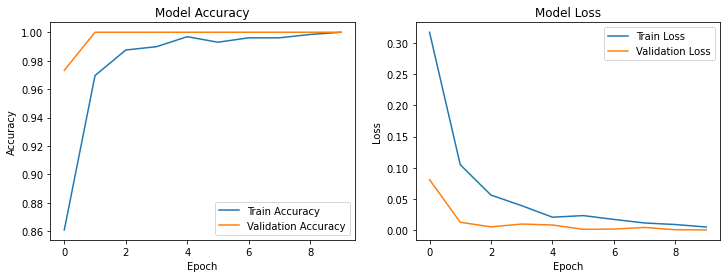

In [12]:

# Plot training & validation accuracy and loss values
def plot_accuracy_loss(history):
    plt.figure(figsize=(12, 4))
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()

plot_accuracy_loss(history)


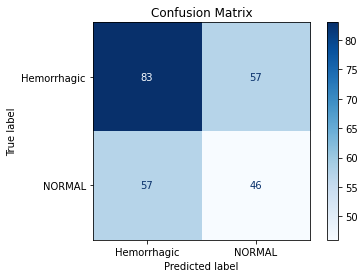

In [13]:

# Confusion Matrix
def plot_confusion_matrix(model, generator):
    # Predict the validation data
    val_generator.reset()
    y_pred = (model.predict(val_generator) > 0.5).astype("int32")
    y_true = val_generator.classes

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_display = ConfusionMatrixDisplay(cm, display_labels=generator.class_indices)
    cm_display.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

plot_confusion_matrix(model, val_generator)

In [22]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt


In [23]:

def get_img_array(img_path, size):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.vgg16.preprocess_input(img_array)  # Change to model-specific preprocessing if needed
    return img_array

In [24]:

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


In [25]:

def apply_heatmap_on_image(img_path, heatmap, intensity=0.4, colormap=cv2.COLORMAP_JET):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, colormap)
    superimposed_img = cv2.addWeighted(img, 1 - intensity, heatmap, intensity, 0)
    return img, superimposed_img


In [26]:

def detect_white_regions(heatmap_img, white_thresh=200):
    gray_img = cv2.cvtColor(heatmap_img, cv2.COLOR_RGB2GRAY)
    _, white_regions = cv2.threshold(gray_img, white_thresh, 255, cv2.THRESH_BINARY)
    white_mask = cv2.bitwise_and(heatmap_img, heatmap_img, mask=white_regions)
    return white_mask

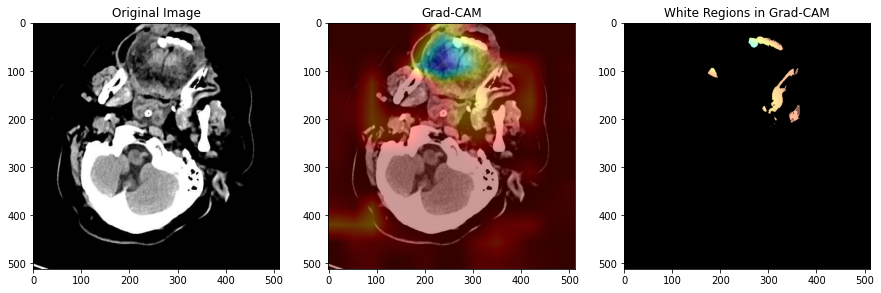

In [ ]:

# Load a pre-trained model and specify the last conv layer name
model = tf.keras.applications.VGG16(weights="imagenet")
last_conv_layer_name = "block5_conv3"

# Load and preprocess the input image
img_path = "19_0_8.jpg"
img_size = (224, 224)
img_array = get_img_array(img_path, img_size)

# Generate Grad-CAM heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# Apply the heatmap to the original image
original_img, gradcam_img = apply_heatmap_on_image(img_path, heatmap)

# Detect white regions in the Grad-CAM overlay
white_mask = detect_white_regions(gradcam_img)

# Display the images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(original_img)

plt.subplot(1, 3, 2)
plt.title("Grad-CAM")
plt.imshow(gradcam_img)

plt.subplot(1, 3, 3)
plt.title("White Regions in Grad-CAM")
plt.imshow(white_mask)

plt.show()

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [29]:

def calculate_white_region_percentage(img_path, white_thresh=200, white_percentage_threshold=10):
    # Load the image
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for display with matplotlib

    # Convert the image to grayscale
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply threshold to detect white regions
    _, white_regions = cv2.threshold(gray_img, white_thresh, 255, cv2.THRESH_BINARY)

    # Calculate the percentage of white pixels
    white_pixels = cv2.countNonZero(white_regions)
    total_pixels = img.shape[0] * img.shape[1]
    white_percentage = (white_pixels / total_pixels) * 100

    # Determine if white space is high or low based on threshold
    white_space_category = "High" if white_percentage > white_percentage_threshold else "Low"
    
    return img_rgb, white_regions, white_percentage, white_space_category


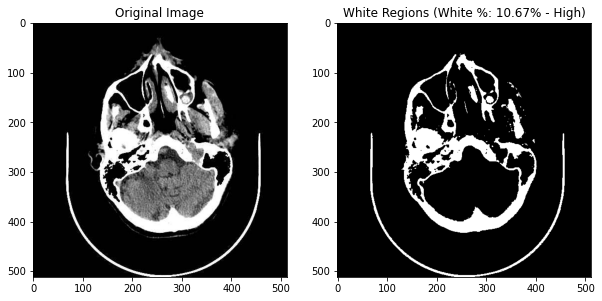

White Space Percentage: 10.67% - High


In [30]:

# Path to the image
img_path = "N25_0_102.jpg"  # Replace with your image path

# Calculate white region percentage
original_img, white_regions, white_percentage, white_space_category = calculate_white_region_percentage(
    img_path, white_thresh=200, white_percentage_threshold=10
)

# Display results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(original_img)

plt.subplot(1, 2, 2)
plt.title(f"White Regions (White %: {white_percentage:.2f}% - {white_space_category})")
plt.imshow(white_regions, cmap='gray')

plt.show()
print(f"White Space Percentage: {white_percentage:.2f}% - {white_space_category}")
